In [528]:
import pandas as pd
import numpy as np
import math
import xgboost
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, PredefinedSplit
from hypopt import GridSearch
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/raw/train.csv")
#df.dropna(inplace=True)
y_label = 'Survived'
#columns_to_remove = ['Name', 'PassengerId']
columns_to_remove = ['PassengerId', 'Ticket']
df.drop(columns=columns_to_remove, inplace=True)
df['Cabin'].fillna('mising', inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode(), inplace=True)
df.dropna(inplace=True)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,7.2500,mising,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,7.9250,mising,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,8.0500,mising,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,13.0000,mising,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,23.4500,mising,S
889,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,30.0000,C148,C


In [529]:
#ctg_columns = ['Sex', 'Ticket', 'Cabin', 'Embarked']
ctg_columns = ['Embarked', 'Cabin']
num_columns = list(set(df.columns) - set(ctg_columns) - set(y_label))

nd_title = [i.split(",")[1].split(".")[0].strip() for i in df["Name"]]
df["Title"] = pd.Series(nd_title)
df["Title"] = df["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', math.nan], 'Rare')
df["Title"] = df["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
df["Title"] = df["Title"].astype(int)
df["Fsize"] = df["SibSp"] + df["Parch"] + 1
df['Single'] = df['Fsize'].map(lambda s: 1 if s == 1 else 0)
df['SmallF'] = df['Fsize'].map(lambda s: 1 if  s == 2  else 0)
df['MedF'] = df['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
df['LargeF'] = df['Fsize'].map(lambda s: 1 if s >= 5 else 0)
df.drop(columns=['Name'], inplace=True)

# Create new feature IsAlone from FamilySize
df['IsAlone'] = 0
df.loc[df['Fsize'] == 1, 'IsAlone'] = 1
# Create new feature CategoricalFare
df['CategoricalFare'] = pd.qcut(df['Fare'], 4)
df.loc[df['Fare'] <= 7.91, 'Fare'] = 0
df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.454), 'Fare'] = 1
df.loc[(df['Fare'] > 14.454) & (df['Fare'] <= 31), 'Fare']   = 2
df.loc[df['Fare'] > 31, 'Fare'] = 3
df['Fare'] = df['Fare'].astype(int)
df['Sex'] = df['Sex'].map( {'female': 0, 'male': 1} ).astype(int)
# Create new feature CategoricalAge
df['CategoricalAge'] = pd.cut(df['Age'], 5)
df.loc[df['Age'] <= 16, 'Age'] = 0
df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
df.loc[df['Age'] > 64, 'Age'] = 4 
df.drop(columns=['CategoricalAge', 'CategoricalFare'], inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,Fsize,Single,SmallF,MedF,LargeF,IsAlone
0,0,3,1,1.0,1,0,0,mising,S,2,2,0,1,0,0,0
1,1,1,0,2.0,1,0,3,C85,C,1,2,0,1,0,0,0
2,1,3,0,1.0,0,0,1,mising,S,1,1,1,0,0,0,1
3,1,1,0,2.0,1,0,3,C123,S,1,2,0,1,0,0,0
4,0,3,1,2.0,0,0,1,mising,S,2,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,1.0,0,0,1,mising,S,1,1,1,0,0,0,1
887,1,1,0,1.0,0,0,2,B42,S,2,1,1,0,0,0,1
888,0,3,0,1.0,1,2,2,mising,S,2,4,0,0,1,0,0
889,1,1,1,1.0,0,0,2,C148,C,3,1,1,0,0,0,1


In [543]:
y_label = 'Survived'
df_train = pd.get_dummies(df, columns=ctg_columns)

y_train = df_train[y_label]
num_columns = ['Pclass', 'Age', 'Sex', 'SibSp', 'Parch', 'Fare' 'Title', 'Fsize', 'Single', 'SmallF', 'MedF', 'LargeF', 'IsAlone']
num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

column_to_nmlz = list(set(df_train.columns) - set([y_label]))
#df_train[column_to_nmlz] = num_pipeline.fit_transform(df_train[column_to_nmlz])
df_train[column_to_nmlz] = num_pipeline.fit_transform(df_train[column_to_nmlz])

train_set, test_set = train_test_split(df_train, test_size=0.2, random_state=42, stratify=y_train)
X_training = train_set.drop(columns=[y_label], axis=1)
X_test = test_set.drop(columns=[y_label], axis=1)
y_training = train_set[y_label]
y_test = test_set[y_label]
for a in df_train.columns:
    print(a)

Survived
Pclass
Sex
Age
SibSp
Parch
Fare
Title
Fsize
Single
SmallF
MedF
LargeF
IsAlone
Embarked_C
Embarked_Q
Embarked_S
Cabin_A10
Cabin_A14
Cabin_A16
Cabin_A19
Cabin_A20
Cabin_A23
Cabin_A24
Cabin_A26
Cabin_A31
Cabin_A32
Cabin_A34
Cabin_A36
Cabin_A5
Cabin_A6
Cabin_A7
Cabin_B101
Cabin_B102
Cabin_B18
Cabin_B19
Cabin_B20
Cabin_B22
Cabin_B3
Cabin_B30
Cabin_B35
Cabin_B37
Cabin_B38
Cabin_B39
Cabin_B4
Cabin_B41
Cabin_B42
Cabin_B49
Cabin_B5
Cabin_B50
Cabin_B51 B53 B55
Cabin_B57 B59 B63 B66
Cabin_B58 B60
Cabin_B69
Cabin_B71
Cabin_B73
Cabin_B77
Cabin_B78
Cabin_B79
Cabin_B80
Cabin_B82 B84
Cabin_B86
Cabin_B94
Cabin_B96 B98
Cabin_C101
Cabin_C103
Cabin_C104
Cabin_C106
Cabin_C110
Cabin_C111
Cabin_C118
Cabin_C123
Cabin_C124
Cabin_C125
Cabin_C126
Cabin_C128
Cabin_C148
Cabin_C2
Cabin_C22 C26
Cabin_C23 C25 C27
Cabin_C30
Cabin_C32
Cabin_C45
Cabin_C46
Cabin_C47
Cabin_C49
Cabin_C50
Cabin_C52
Cabin_C54
Cabin_C62 C64
Cabin_C65
Cabin_C68
Cabin_C7
Cabin_C70
Cabin_C78
Cabin_C82
Cabin_C83
Cabin_C85
Cabin_C86
Cabin

begin training random forest...
training finished, get predictions...
on training set:
n_correct:595
accuracy: 0.8368495077355836
on testing set:
n_correct:144
accuracy: 0.8089887640449438
score: 0.8089887640449438


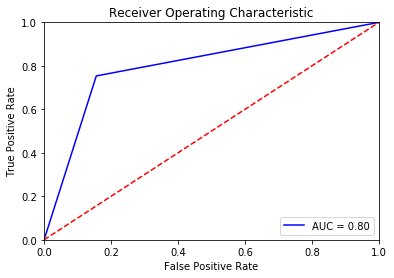

In [432]:
def get_prediction_precision(model, testing_data, testing_labels):
    y_pred = model.predict(testing_data)
    n_correct = sum(y_pred == testing_labels)
    print("n_correct:{}".format(n_correct))
    print("accuracy: {}".format(float(n_correct) / len(y_pred)))

#rf_clf = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=6)
rf_clf = rf_best
print("begin training random forest...")
rf_clf.fit(X_training, y_training)
print("training finished, get predictions...")
#dump(rf_clf, '../models/rf.joblib')
print("on training set:")
get_prediction_precision(rf_clf, X_training, y_training)
print("on testing set:")
get_prediction_precision(rf_clf, X_test, y_test)
print("score: {}".format(rf_clf.score(X_test, y_test)))
plot_AUC(rf_clf)

In [154]:
df_test = pd.read_csv("../data/raw/test.csv")
df_test['Cabin'].fillna('mising', inplace=True)
df_test['Age'].fillna(df['Age'].mean(), inplace=True)
df_test['Fare'].fillna(df['Fare'].mean(), inplace=True)

test_final_columns = list(df_train.columns)
test_final_columns.remove(y_label)
df_test_dummy = pd.DataFrame(columns=test_final_columns)
for idx, row in df_test.iterrows():
    series_dict = {}
    for col in test_final_columns:
        if '_' in col:
            ctg_name, ctg_value = col.split('_')
            series_dict[col] = 1 if row[ctg_name] == ctg_value else 0
        else:
            series_dict[col] = row[col]
    df_test_dummy= df_test_dummy.append(series_dict, ignore_index=True)
df_test_dummy

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising,Embarked_C,Embarked_Q,Embarked_S
0,3.0,34.500000,0.0,0.0,7.8292,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,3.0,47.000000,1.0,0.0,7.0000,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2.0,62.000000,0.0,0.0,9.6875,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3.0,27.000000,0.0,0.0,8.6625,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,3.0,22.000000,1.0,1.0,12.2875,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3.0,29.653446,0.0,0.0,8.0500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
414,1.0,39.000000,0.0,0.0,108.9000,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
415,3.0,38.500000,0.0,0.0,7.2500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
416,3.0,29.653446,0.0,0.0,8.0500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [155]:
df_test_dummy[column_to_nmlz] = num_pipeline.fit_transform(df_test_dummy[column_to_nmlz])
df_test_dummy

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising,Embarked_C,Embarked_Q,Embarked_S
0,0.873482,0.345019,-0.499470,-0.400248,-0.498253,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,2.843757,-1.350676
1,0.873482,1.335362,0.616992,-0.400248,-0.513120,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
2,-0.315819,2.523773,-0.499470,-0.400248,-0.464935,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,2.843757,-1.350676
3,0.873482,-0.249187,-0.499470,-0.400248,-0.483313,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
4,0.873482,-0.645324,0.616992,0.619896,-0.418318,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.873482,-0.038961,-0.499470,-0.400248,-0.494294,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
414,-1.505120,0.701542,-0.499470,-0.400248,1.313898,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,-1.895628,1.760125,-0.351647,-1.350676
415,0.873482,0.661929,-0.499470,-0.400248,-0.508638,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
416,0.873482,-0.038961,-0.499470,-0.400248,-0.494294,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370


Random Forest

In [521]:
def dict_product(d):
    keys = d.keys()
    for element in product(*d.values()):
        yield dict(zip(keys, element))

def GridSearchWithVal(model_class, param_grid, sub_class=None, sub_param_grid=None):
    combinations = list(dict_product(param_grid))
    best_acc = 0
    best_comb, best_model = None, None
    print("{} combinations in total".format(len(combinations)))
    for comb in combinations:
        print(comb)
        
        if sub_class is None:
            model = model_class(**comb)
            model.fit(X_training, y_training)
            y_pred = model.predict(X_test)
            n_correct = sum(y_pred == y_test)
            acc = float(n_correct) / len(y_pred)
            if acc > best_acc:
                best_acc = acc
                best_comb = comb
                best_model = model
        else:
            sub_combinations = list(dict_product(sub_param_grid))
            for sub_comb in sub_combinations:
                estimator = sub_class(**sub_comb)
                model = model_class(estimator, **comb)
                model.fit(X_training, y_training)
                y_pred = model.predict(X_test)
                n_correct = sum(y_pred == y_test)
                acc = float(n_correct) / len(y_pred)
                if acc > best_acc:
                    best_acc = acc
                    best_comb = comb
                    best_model = model
        
    print("best params:{}".format(best_comb))     
    print("best acc:{}".format(best_acc))
    return best_model

In [479]:
rfc = RandomForestClassifier
rf_param_grid = {"n_estimators" : [100, 150, 200, 250, 300],
                  "criterion" : ["gini", "entropy"],
                  "max_depth": [3, 4, 5, 6, 7, None],
                  "max_features": ['auto', None],
                  "min_samples_split": [2, 3, 10],
                  "min_samples_leaf": [1, 3, 10],
                  "bootstrap": [True, False]
                 }
# gs_rf = GridSearchCV(rfc, param_grid=rf_param_grid, cv=3, scoring="accuracy", n_jobs=4, verbose=1)
# gs_rf.fit(X_training, y_training)
GridSearchWithVal(rfc, rf_param_grid)

2160 combinations in total
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 3, 'max_features':

{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_sam

{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split

{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_split': 3, 'min_sam

{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto

...

{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_sample

{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto

{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_sample

{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 10, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': None, 

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=5, max_features=None,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=3, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=200,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [484]:
rf_best = RandomForestClassifier(n_estimators=200, criterion='entropy', max_depth=5, max_features=None,
                                 min_samples_split=2, min_samples_leaf=3, bootstrap=True)
rf_best.fit(X_training, y_training)
get_prediction_precision(rf_best, X_test, y_test)

n_correct:146
accuracy: 0.8202247191011236


In [163]:
y_pred = rf_best.predict(df_test_dummy)
df_output = pd.DataFrame(data={'PassengerId': df_test['PassengerId'], 'Survived': y_pred})
df_output.to_csv("../data/processed/submission.csv", index=False)

MLP

Keras model constructed
Train on 711 samples, validate on 178 samples
Epoch 1/500
711/711 [==============================] - 3s 4ms/step - loss: 0.7337 - acc: 0.5527 - val_loss: 0.7451 - val_acc: 0.5730
Epoch 2/500
711/711 [==============================] - 0s 216us/step - loss: 0.7311 - acc: 0.5640 - val_loss: 0.7426 - val_acc: 0.5730
Epoch 3/500
711/711 [==============================] - 0s 190us/step - loss: 0.7287 - acc: 0.5710 - val_loss: 0.7401 - val_acc: 0.5843
Epoch 4/500
711/711 [==============================] - 0s 238us/step - loss: 0.7263 - acc: 0.5724 - val_loss: 0.7377 - val_acc: 0.5899
Epoch 5/500
711/711 [==============================] - 0s 208us/step - loss: 0.7240 - acc: 0.5724 - val_loss: 0.7353 - val_acc: 0.5955
Epoch 6/500
711/711 [==============================] - 0s 213us/step - loss: 0.7217 - acc: 0.5724 - val_loss: 0.7329 - val_acc: 0.6011
Epoch 7/500
711/711 [==============================] - 0s 187us/step - loss: 0.7194 - acc: 0.5724 - val_loss: 0.7306 - val

Epoch 61/500
711/711 [==============================] - 0s 169us/step - loss: 0.6283 - acc: 0.6793 - val_loss: 0.6406 - val_acc: 0.6629
Epoch 62/500
711/711 [==============================] - 0s 159us/step - loss: 0.6270 - acc: 0.6779 - val_loss: 0.6393 - val_acc: 0.6629
Epoch 63/500
711/711 [==============================] - 0s 161us/step - loss: 0.6257 - acc: 0.6779 - val_loss: 0.6381 - val_acc: 0.6629
Epoch 64/500
711/711 [==============================] - 0s 157us/step - loss: 0.6244 - acc: 0.6807 - val_loss: 0.6368 - val_acc: 0.6629
Epoch 65/500
711/711 [==============================] - 0s 160us/step - loss: 0.6231 - acc: 0.6821 - val_loss: 0.6356 - val_acc: 0.6629
Epoch 66/500
711/711 [==============================] - 0s 162us/step - loss: 0.6218 - acc: 0.6835 - val_loss: 0.6344 - val_acc: 0.6629
Epoch 67/500
711/711 [==============================] - 0s 161us/step - loss: 0.6205 - acc: 0.6850 - val_loss: 0.6332 - val_acc: 0.6629
Epoch 68/500
711/711 [==========================

711/711 [==============================] - 0s 166us/step - loss: 0.5633 - acc: 0.7595 - val_loss: 0.5821 - val_acc: 0.7528
Epoch 122/500
711/711 [==============================] - 0s 157us/step - loss: 0.5624 - acc: 0.7567 - val_loss: 0.5814 - val_acc: 0.7528
Epoch 123/500
711/711 [==============================] - 0s 154us/step - loss: 0.5615 - acc: 0.7553 - val_loss: 0.5807 - val_acc: 0.7528
Epoch 124/500
711/711 [==============================] - 0s 154us/step - loss: 0.5607 - acc: 0.7525 - val_loss: 0.5800 - val_acc: 0.7528
Epoch 125/500
711/711 [==============================] - 0s 160us/step - loss: 0.5598 - acc: 0.7525 - val_loss: 0.5793 - val_acc: 0.7528
Epoch 126/500
711/711 [==============================] - 0s 161us/step - loss: 0.5591 - acc: 0.7525 - val_loss: 0.5787 - val_acc: 0.7528
Epoch 127/500
711/711 [==============================] - 0s 153us/step - loss: 0.5583 - acc: 0.7511 - val_loss: 0.5780 - val_acc: 0.7584
Epoch 128/500
711/711 [==============================] 

Epoch 181/500
711/711 [==============================] - 0s 160us/step - loss: 0.5228 - acc: 0.7722 - val_loss: 0.5514 - val_acc: 0.7921
Epoch 182/500
711/711 [==============================] - 0s 156us/step - loss: 0.5223 - acc: 0.7707 - val_loss: 0.5511 - val_acc: 0.7921
Epoch 183/500
711/711 [==============================] - 0s 154us/step - loss: 0.5217 - acc: 0.7736 - val_loss: 0.5507 - val_acc: 0.7921
Epoch 184/500
711/711 [==============================] - 0s 150us/step - loss: 0.5212 - acc: 0.7707 - val_loss: 0.5504 - val_acc: 0.7921
Epoch 185/500
711/711 [==============================] - 0s 157us/step - loss: 0.5207 - acc: 0.7707 - val_loss: 0.5501 - val_acc: 0.7921
Epoch 186/500
711/711 [==============================] - 0s 162us/step - loss: 0.5202 - acc: 0.7707 - val_loss: 0.5497 - val_acc: 0.7921
Epoch 187/500
711/711 [==============================] - 0s 151us/step - loss: 0.5197 - acc: 0.7722 - val_loss: 0.5494 - val_acc: 0.7921
Epoch 188/500
711/711 [==================

Epoch 241/500
711/711 [==============================] - 0s 161us/step - loss: 0.4962 - acc: 0.7792 - val_loss: 0.5358 - val_acc: 0.7921
Epoch 242/500
711/711 [==============================] - 0s 161us/step - loss: 0.4958 - acc: 0.7806 - val_loss: 0.5357 - val_acc: 0.7921
Epoch 243/500
711/711 [==============================] - 0s 156us/step - loss: 0.4954 - acc: 0.7806 - val_loss: 0.5355 - val_acc: 0.7921
Epoch 244/500
711/711 [==============================] - 0s 157us/step - loss: 0.4951 - acc: 0.7806 - val_loss: 0.5353 - val_acc: 0.7921
Epoch 245/500
711/711 [==============================] - 0s 154us/step - loss: 0.4947 - acc: 0.7820 - val_loss: 0.5351 - val_acc: 0.7921
Epoch 246/500
711/711 [==============================] - 0s 160us/step - loss: 0.4943 - acc: 0.7820 - val_loss: 0.5350 - val_acc: 0.7865
Epoch 247/500
711/711 [==============================] - 0s 160us/step - loss: 0.4940 - acc: 0.7834 - val_loss: 0.5348 - val_acc: 0.7865
Epoch 248/500
711/711 [==================

Epoch 301/500
711/711 [==============================] - 0s 158us/step - loss: 0.4777 - acc: 0.7890 - val_loss: 0.5290 - val_acc: 0.7865
Epoch 302/500
711/711 [==============================] - 0s 155us/step - loss: 0.4774 - acc: 0.7890 - val_loss: 0.5289 - val_acc: 0.7865
Epoch 303/500
711/711 [==============================] - 0s 160us/step - loss: 0.4772 - acc: 0.7890 - val_loss: 0.5288 - val_acc: 0.7865
Epoch 304/500
711/711 [==============================] - 0s 149us/step - loss: 0.4769 - acc: 0.7876 - val_loss: 0.5288 - val_acc: 0.7865
Epoch 305/500
711/711 [==============================] - 0s 154us/step - loss: 0.4767 - acc: 0.7876 - val_loss: 0.5287 - val_acc: 0.7865
Epoch 306/500
711/711 [==============================] - 0s 157us/step - loss: 0.4764 - acc: 0.7876 - val_loss: 0.5286 - val_acc: 0.7865
Epoch 307/500
711/711 [==============================] - 0s 154us/step - loss: 0.4762 - acc: 0.7876 - val_loss: 0.5286 - val_acc: 0.7865
Epoch 308/500
711/711 [==================

Epoch 361/500
711/711 [==============================] - 0s 156us/step - loss: 0.4640 - acc: 0.7975 - val_loss: 0.5269 - val_acc: 0.7865
Epoch 362/500
711/711 [==============================] - 0s 155us/step - loss: 0.4638 - acc: 0.7975 - val_loss: 0.5269 - val_acc: 0.7865
Epoch 363/500
711/711 [==============================] - 0s 149us/step - loss: 0.4636 - acc: 0.7975 - val_loss: 0.5269 - val_acc: 0.7865
Epoch 364/500
711/711 [==============================] - 0s 155us/step - loss: 0.4634 - acc: 0.7975 - val_loss: 0.5268 - val_acc: 0.7865
Epoch 365/500
711/711 [==============================] - 0s 156us/step - loss: 0.4632 - acc: 0.7975 - val_loss: 0.5268 - val_acc: 0.7865
Epoch 366/500
711/711 [==============================] - 0s 158us/step - loss: 0.4630 - acc: 0.7975 - val_loss: 0.5268 - val_acc: 0.7865
Epoch 367/500
711/711 [==============================] - 0s 160us/step - loss: 0.4628 - acc: 0.7975 - val_loss: 0.5268 - val_acc: 0.7865
Epoch 368/500
711/711 [==================

Epoch 421/500
711/711 [==============================] - 0s 151us/step - loss: 0.4533 - acc: 0.8073 - val_loss: 0.5274 - val_acc: 0.7865
Epoch 422/500
711/711 [==============================] - 0s 161us/step - loss: 0.4531 - acc: 0.8073 - val_loss: 0.5275 - val_acc: 0.7865
Epoch 423/500
711/711 [==============================] - 0s 162us/step - loss: 0.4530 - acc: 0.8087 - val_loss: 0.5275 - val_acc: 0.7865
Epoch 424/500
711/711 [==============================] - 0s 158us/step - loss: 0.4528 - acc: 0.8087 - val_loss: 0.5276 - val_acc: 0.7865
Epoch 425/500
711/711 [==============================] - 0s 159us/step - loss: 0.4526 - acc: 0.8087 - val_loss: 0.5276 - val_acc: 0.7865
Epoch 426/500
711/711 [==============================] - 0s 156us/step - loss: 0.4525 - acc: 0.8087 - val_loss: 0.5276 - val_acc: 0.7865
Epoch 427/500
711/711 [==============================] - 0s 161us/step - loss: 0.4523 - acc: 0.8087 - val_loss: 0.5277 - val_acc: 0.7865
Epoch 428/500
711/711 [==================

Epoch 481/500
711/711 [==============================] - 0s 160us/step - loss: 0.4438 - acc: 0.8115 - val_loss: 0.5298 - val_acc: 0.7865
Epoch 482/500
711/711 [==============================] - 0s 157us/step - loss: 0.4437 - acc: 0.8115 - val_loss: 0.5298 - val_acc: 0.7865
Epoch 483/500
711/711 [==============================] - 0s 154us/step - loss: 0.4435 - acc: 0.8115 - val_loss: 0.5299 - val_acc: 0.7865
Epoch 484/500
711/711 [==============================] - 0s 160us/step - loss: 0.4434 - acc: 0.8115 - val_loss: 0.5299 - val_acc: 0.7865
Epoch 485/500
711/711 [==============================] - 0s 157us/step - loss: 0.4432 - acc: 0.8129 - val_loss: 0.5299 - val_acc: 0.7865
Epoch 486/500
711/711 [==============================] - 0s 154us/step - loss: 0.4431 - acc: 0.8115 - val_loss: 0.5300 - val_acc: 0.7865
Epoch 487/500
711/711 [==============================] - 0s 152us/step - loss: 0.4430 - acc: 0.8129 - val_loss: 0.5300 - val_acc: 0.7865
Epoch 488/500
711/711 [==================

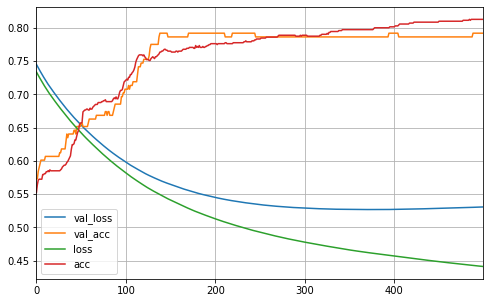

In [393]:
def create_keras_model(optimizer='adam', neuron=50, init='lecun_normal', act_alpha=0.01):
    model_sequences = [
        keras.layers.Dense(units=neuron, kernel_initializer=init, 
                           activation='elu',
                           input_shape=X_training.shape[1:]
                          ),
        
        #keras.layers.LeakyReLU(alpha=act_alpha)
    ]

    for i in range(5):
        model_sequences.append(keras.layers.Dense(units=neuron, kernel_initializer=init,
                                                  activation='elu',
                                                  input_shape=X_training.shape[1:]))
        #model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    #model_sequences.append(keras.layers.BatchNormalization())
    model_sequences.append(Dense(units=1, name='score_output', activation='sigmoid'))
    #model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    nn_model = keras.models.Sequential(model_sequences)
    nn_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return nn_model

optimizer = keras.optimizers.Adadelta(lr=1e-3)
nn_model = create_keras_model(optimizer=optimizer, neuron=100, init='lecun_uniform', act_alpha=0.05)
print("Keras model constructed")
early_stopping_cb = EarlyStopping(patience=20)
history = nn_model.fit(X_training, y_training, validation_data=(X_test, y_test), epochs=500, callbacks=[], verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [304]:
def plot_AUC(model):
    preds = model.predict(X_test)
    fpr, tpr, threshold = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label='AUC = %0.2f' % roc_auc)
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

XGBoost

In [535]:
xgb_param_grid = {"objective" : ['binary:logistic', 'binary:hinge'],
                  "base_score" : [0.01, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1]
                 }
xgbc_best = GridSearchWithVal(xgboost.XGBClassifier, xgb_param_grid)

14 combinations in total
{'objective': 'binary:logistic', 'base_score': 0.01}
{'objective': 'binary:logistic', 'base_score': 0.03}
{'objective': 'binary:logistic', 'base_score': 0.04}
{'objective': 'binary:logistic', 'base_score': 0.05}
{'objective': 'binary:logistic', 'base_score': 0.06}
{'objective': 'binary:logistic', 'base_score': 0.08}
{'objective': 'binary:logistic', 'base_score': 0.1}
{'objective': 'binary:hinge', 'base_score': 0.01}
{'objective': 'binary:hinge', 'base_score': 0.03}
{'objective': 'binary:hinge', 'base_score': 0.04}
{'objective': 'binary:hinge', 'base_score': 0.05}
{'objective': 'binary:hinge', 'base_score': 0.06}
{'objective': 'binary:hinge', 'base_score': 0.08}
{'objective': 'binary:hinge', 'base_score': 0.1}
best params:{'objective': 'binary:logistic', 'base_score': 0.05}
best acc:0.8033707865168539


begin training XGBoost...
training finished, get predictions...
n_correct:139
accuracy: 0.7808988764044944
score: 0.7808988764044944


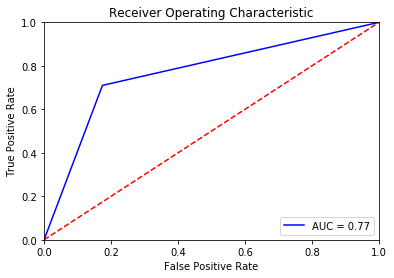

In [507]:
xgb_clf = xgb_best
print("begin training XGBoost...")
xgb_clf.fit(X_training, y_training, verbose=True)
print("training finished, get predictions...")
#dump(xgb_clf, '../models/xgb.joblib')
get_prediction_precision(xgb_clf, X_test, y_test)
print("score: {}".format(xgb_clf.score(X_test, y_test)))
plot_AUC(xgb_clf)

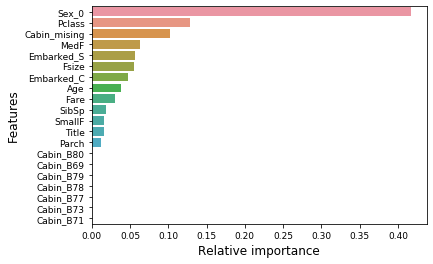

In [493]:
xgb_clf.feature_importances_

def plot_feature_importance(model):
    indices = np.argsort(model.feature_importances_)[::-1][:20]
    g = sns.barplot(y=X_training.columns[indices][:40],x = model.feature_importances_[indices][:40] , orient='h')
    g.set_xlabel("Relative importance",fontsize=12)
    g.set_ylabel("Features",fontsize=12)
    g.tick_params(labelsize=9)
    
plot_feature_importance(xgb_clf)

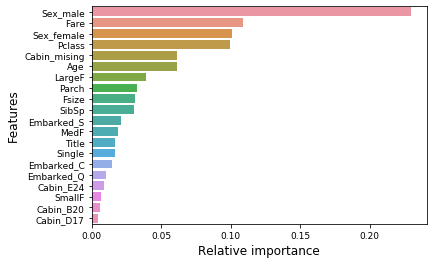

In [357]:
plot_feature_importance(rf_clf)

Gradient Boosting Classifier

In [536]:
gb_param_grid = {"n_estimators" : [50, 100, 150, 200, 250],
                  "loss" : ["deviance"],
                  "learning_rate": [0.03, 0.04, 0.05, 0.06, 0.08, 0.1],
                  "max_depth": [4, 5, 6, 7],
                  "min_samples_leaf": [50, 100, 120],
                  "max_features": [0.3, 0.1, None] 
                }
gbc_best = GridSearchWithVal(GradientBoostingClassifier, gb_param_grid)

1080 combinations in total
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 50, 'max_feature

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features'

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{

{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_f

...

{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_

{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_featur

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_f

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 120, 'max_f

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features

n_correct:141
accuracy: 0.7921348314606742


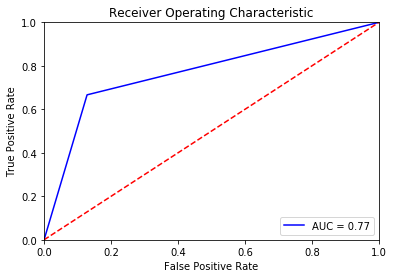

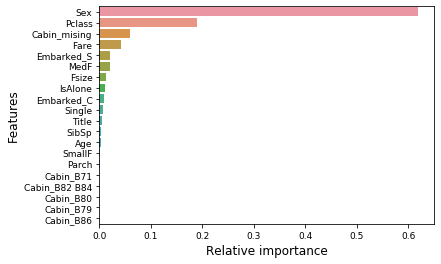

In [518]:
GB_clf = gbc_best
GB_clf.fit(X_training, y_training)
get_prediction_precision(GB_clf, X_test, y_test)
plot_AUC(GB_clf)
plot_feature_importance(GB_clf)

AdaBoost Classifier with Decision Tree

In [537]:
gdtc = DecisionTreeClassifier()
adaDTC = AdaBoostClassifier(gdtc, random_state=7)
gb_param_grid = {"algorithm" : ["SAMME","SAMME.R"],
                 "n_estimators" :[150, 200, 250, 280, 300],
                 "learning_rate":  [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.01]
                }
sub_param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"]
}
gs_gdt = GridSearchCV(adaDTC, param_grid=gb_param_grid, cv=3, scoring="accuracy", n_jobs=4, verbose=1)
adbc_best = GridSearchWithVal(AdaBoostClassifier, gb_param_grid, DecisionTreeClassifier, sub_param_grid)

70 combinations in total
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.03}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.04}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.05}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.06}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.07}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.08}
{'algorithm': 'SAMME', 'n_estimators': 150, 'learning_rate': 0.01}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.03}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.04}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.05}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.06}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.07}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.08}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.01}
{'algorithm': 'SAMME', 'n_estimators'

n_correct:134
accuracy: 0.7528089887640449


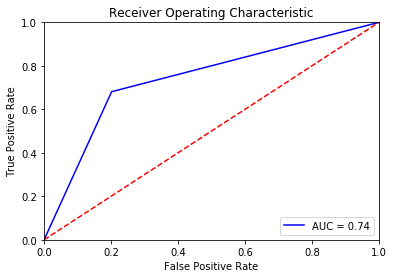

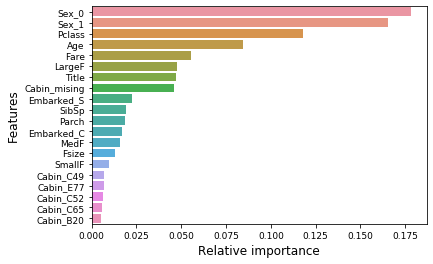

In [437]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=4)
#adb_clf = AdaBoostClassifier(base_estimator=dtc, algorithm='SAMME', n_estimators=200)
adb_clf = gdt_best
adb_clf.fit(X_training, y_training)
get_prediction_precision(adb_clf, X_test, y_test)
plot_AUC(adb_clf)
plot_feature_importance(adb_clf)

n_correct:147
accuracy: 0.8258426966292135


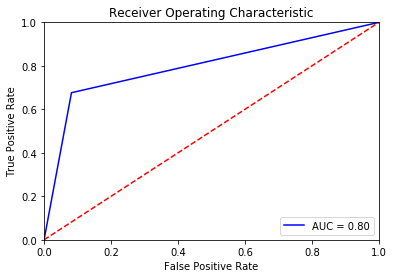

In [538]:
voting_clf = VotingClassifier(estimators=[
    ('rfc', rf_best), ('xgb', xgbc_best), ('gbc', gbc_best), ('adb', adbc_best)], voting='hard')
voting_clf = voting_clf.fit(X_training, y_training)
get_prediction_precision(voting_clf, X_test, y_test)
plot_AUC(voting_clf)
#plot_feature_importance(voting_clf)

In [545]:
df_test = pd.read_csv("../data/raw/test.csv")

df_test['Cabin'].fillna('mising', inplace=True)
df_test['Age'].fillna(df['Age'].mean(), inplace=True)
df_test['Fare'].fillna(df['Fare'].mean(), inplace=True)
df_test['Embarked'].fillna(df['Embarked'].mode(), inplace=True)
df_test.isna().sum()

passenger_ids = df_test['PassengerId']
columns_to_remove = ['PassengerId', 'Ticket']
df_test.drop(columns=columns_to_remove, inplace=True)

nd_title_test = [i.split(",")[1].split(".")[0].strip() for i in df_test["Name"]]
df_test["Title"] = pd.Series(nd_title_test)
df_test["Title"] = df_test["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', math.nan], 'Rare')
df_test["Title"] = df_test["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
df_test["Title"] = df_test["Title"].astype(int)
df_test["Fsize"] = df_test["SibSp"] + df_test["Parch"] + 1
df_test['Single'] = df_test['Fsize'].map(lambda s: 1 if s == 1 else 0)
df_test['SmallF'] = df_test['Fsize'].map(lambda s: 1 if  s == 2  else 0)
df_test['MedF'] = df_test['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
df_test['LargeF'] = df_test['Fsize'].map(lambda s: 1 if s >= 5 else 0)
df_test.drop(columns=['Name'], inplace=True)

# Create new feature IsAlone from FamilySize
df_test['IsAlone'] = 0
df_test.loc[df_test['Fsize'] == 1, 'IsAlone'] = 1
# Create new feature CategoricalFare
df_test['CategoricalFare'] = pd.qcut(df_test['Fare'], 4)
df_test.loc[df_test['Fare'] <= 7.91, 'Fare'] = 0
df_test.loc[(df_test['Fare'] > 7.91) & (df_test['Fare'] <= 14.454), 'Fare'] = 1
df_test.loc[(df_test['Fare'] > 14.454) & (df_test['Fare'] <= 31), 'Fare']   = 2
df_test.loc[df_test['Fare'] > 31, 'Fare'] = 3
df_test['Fare'] = df_test['Fare'].astype(int)
df_test['Sex'] = df_test['Sex'].map( {'female': 0, 'male': 1} ).astype(int)
# Create new feature CategoricalAge
df_test['CategoricalAge'] = pd.cut(df_test['Age'], 5)
df_test.loc[df_test['Age'] <= 16, 'Age'] = 0
df_test.loc[(df_test['Age'] > 16) & (df_test['Age'] <= 32), 'Age'] = 1
df_test.loc[(df_test['Age'] > 32) & (df_test['Age'] <= 48), 'Age'] = 2
df_test.loc[(df_test['Age'] > 48) & (df_test['Age'] <= 64), 'Age'] = 3
df_test.loc[df_test['Age'] > 64, 'Age'] = 4 
df_test.drop(columns=['CategoricalAge', 'CategoricalFare'], inplace=True)


test_final_columns = list(df_train.columns)
test_final_columns.remove(y_label)
df_test_dummy = pd.DataFrame(columns=test_final_columns)
for idx, row in df_test.iterrows():
    series_dict = {}
    for col in test_final_columns:
        if '_' in col:
            ctg_name, ctg_value = col.split('_')
            series_dict[col] = 1 if row[ctg_name] == ctg_value else 0
        else:
            series_dict[col] = row[col]
    df_test_dummy= df_test_dummy.append(series_dict, ignore_index=True)


df_test_dummy[column_to_nmlz] = num_pipeline.fit_transform(df_test_dummy[column_to_nmlz])
df_test_dummy

,Pclass,Sex,Age,SibSp,Parch,Fare,Title,Fsize,Single,SmallF,...,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising
0,0.873482,0.755929,0.967861,-0.499470,-0.400248,-1.294669,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
1,0.873482,-1.322876,0.967861,0.616992,-0.400248,-1.294669,-0.900744,0.105643,-1.238278,2.156073,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
2,-0.315819,0.755929,2.040979,-0.499470,-0.400248,-0.423217,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
3,0.873482,0.755929,-0.105258,-0.499470,-0.400248,-0.423217,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
4,0.873482,-1.322876,-0.105258,0.616992,0.619896,-0.423217,-0.900744,0.764728,-1.238278,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.873482,0.755929,-1.178377,-0.499470,-0.400248,-0.423217,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
414,-1.505120,-1.322876,0.967861,-0.499470,-0.400248,1.319687,2.359091,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,-1.895628
415,0.873482,0.755929,0.967861,-0.499470,-0.400248,-1.294669,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530
416,0.873482,0.755929,-1.178377,-0.499470,-0.400248,-0.423217,0.729174,-0.553443,0.807573,-0.463806,...,0.0,-0.04897,0.0,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530


In [546]:
y_pred_3 = voting_clf.predict(df_test_dummy)
df_output_3 = pd.DataFrame(data={'PassengerId': passenger_ids, 'Survived': y_pred_3})
df_output_3
df_output_3.to_csv("../data/processed/submission_3.csv", index=False)